In [2]:
from torch.utils.data import DataLoader
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from src.terramesh import build_terramesh_dataset, Transpose, MultimodalTransforms


INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.8 (you have 1.4.10). Upgrade using: pip install --upgrade albumentations


In [3]:
# Define all image modalities
#modalities = ["S2L2A", "S2L1C", "S2RGB", "S1GRD", "S1RTC", "DEM", "NDVI"]
modalities = ["DEM"]
LOCAL_TERRAMESH_PATH = "/dss/dsstbyfs02/pn49cu/pn49cu-dss-0020/terramesh_val/data/TerraMesh/"

# Define multimodal transform function that converts the data into the expected shape from albumentations 
val_transform = MultimodalTransforms(
    transforms=A.Compose([  # We use albumentations because of the shared transform between image modalities
        Transpose([1, 2, 0]),  # Convert data to channel last (expected shape from albumentations)
        A.CenterCrop(224, 224),  # Use center crop in val split
        # A.RandomCrop(224, 224),  # Use random crop in train split
        # A.D4(),  # Optionally, use random flipping and rotation for the train split
        ToTensorV2(),  # Convert to tensor and back to channel first
    ],
        is_check_shapes=False,  # Not needed because of aligned data in TerraMesh
        additional_targets={m: "image" for m in modalities},  # Only image keys
    ),
    #non_image_modalities=["__key__", "__url__"],  # Additional non-image keys
    non_image_modalities=["__key__", "__url__", "center_lon", "center_lat", "cloud_mask"] + ["time_" + m for m in modalities]
)

dataset = build_terramesh_dataset(
    path=LOCAL_TERRAMESH_PATH,
    modalities=modalities,
    split="val",
    shuffle=False,
    transform=val_transform,
    batch_size=1,
    return_metadata=True,
)

# Set batch size to None because batching is handled by WebDataset.
dataloader = DataLoader(dataset, batch_size=None, num_workers=32, persistent_workers=True, prefetch_factor=1)

lon_list = []
lat_list = []

# Iterate over the dataloader
for i, batch in enumerate(dataloader):
    #print("Batch keys:", list(batch.keys()))
    # Batch keys: ["__key__", "__url__", "S2L2A", "S2L1C", "S2RGB", "S1RTC", "DEM", "NDVI", "LULC"]
    # Because S1RTC and S1GRD are not present for all samples, each batch only includes one S1 version.

    #print("Data shape:", batch["S2L2A"].shape)
    lon = batch['center_lon'].item() if isinstance(batch['center_lon'], torch.Tensor) else float(batch['center_lon'])
    lat = batch['center_lat'].item() if isinstance(batch['center_lat'], torch.Tensor) else float(batch['center_lat'])

    lon_list.append(lon)
    lat_list.append(lat)

print(f"Total samples collected: {len(lon_list):,}")

Total samples collected: 89,088


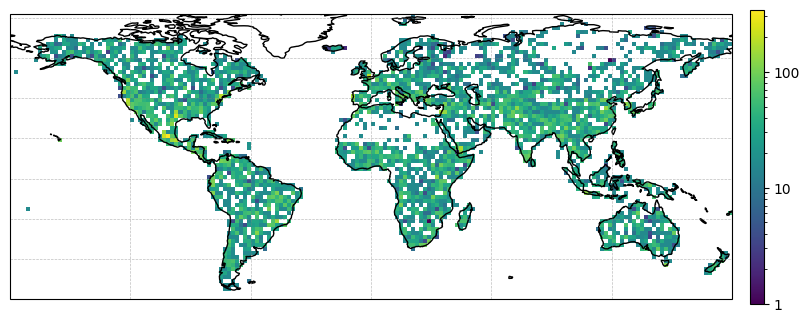

In [4]:
# Convert to NumPy for Matplotlib
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
import matplotlib.ticker as mtick

GRID_SIZE = 2  # in degrees

lon_arr = np.array(lon_list)
lat_arr = np.array(lat_list)

# Create a Plate Carree (equirectangular) projection – WGS84 coordinates map 1:1
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9, 4.5))
ax = plt.axes(projection=proj)

# Add nice background features
#ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black')
ax.coastlines(resolution='110m')
gridlines = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray',
                         alpha=0.5, linestyle='--')
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.x_inline = False
gridlines.y_inline = False

# Define bin edges (lon: -180 → 180, lat: -90 → 90)
lon_bins = np.arange(-180, 181, GRID_SIZE)   # 360 bins
lat_bins = np.arange(-60,  83, GRID_SIZE)    # 180 bins

# Compute the 2‑D histogram
counts, lon_edges, lat_edges = np.histogram2d(
    lon_arr,
    lat_arr,
    bins=[lon_bins, lat_bins]
)

# Transpose because pcolormesh expects shape (Ny, Nx)
counts = counts.T   # (lat, lon)

# Plot with pcolormesh; use LogNorm for logarithmic colour scaling
mesh = ax.pcolormesh(
    lon_edges,
    lat_edges,
    counts,
    cmap='viridis',
    norm=LogNorm(),          # log‑scale, ignore empty cells
    transform=proj,
    shading='auto'                 # smooth edges
)

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical',
                    shrink=0.7, pad=0.02)
#cbar.set_label('Sample count per str(GRID_SIZE)°×str(GRID_SIZE)° cell (log scale)')

# formatter: turn scientific notation into plain integers
cbar.formatter = mtick.FuncFormatter(lambda x, _: f'{int(x):,}' if x >= 1 else f'{x:.2f}')
cbar.update_ticks()

plt.tight_layout()
plt.savefig('../figures/heatmap.png', dpi=300, bbox_inches='tight')
plt.show()